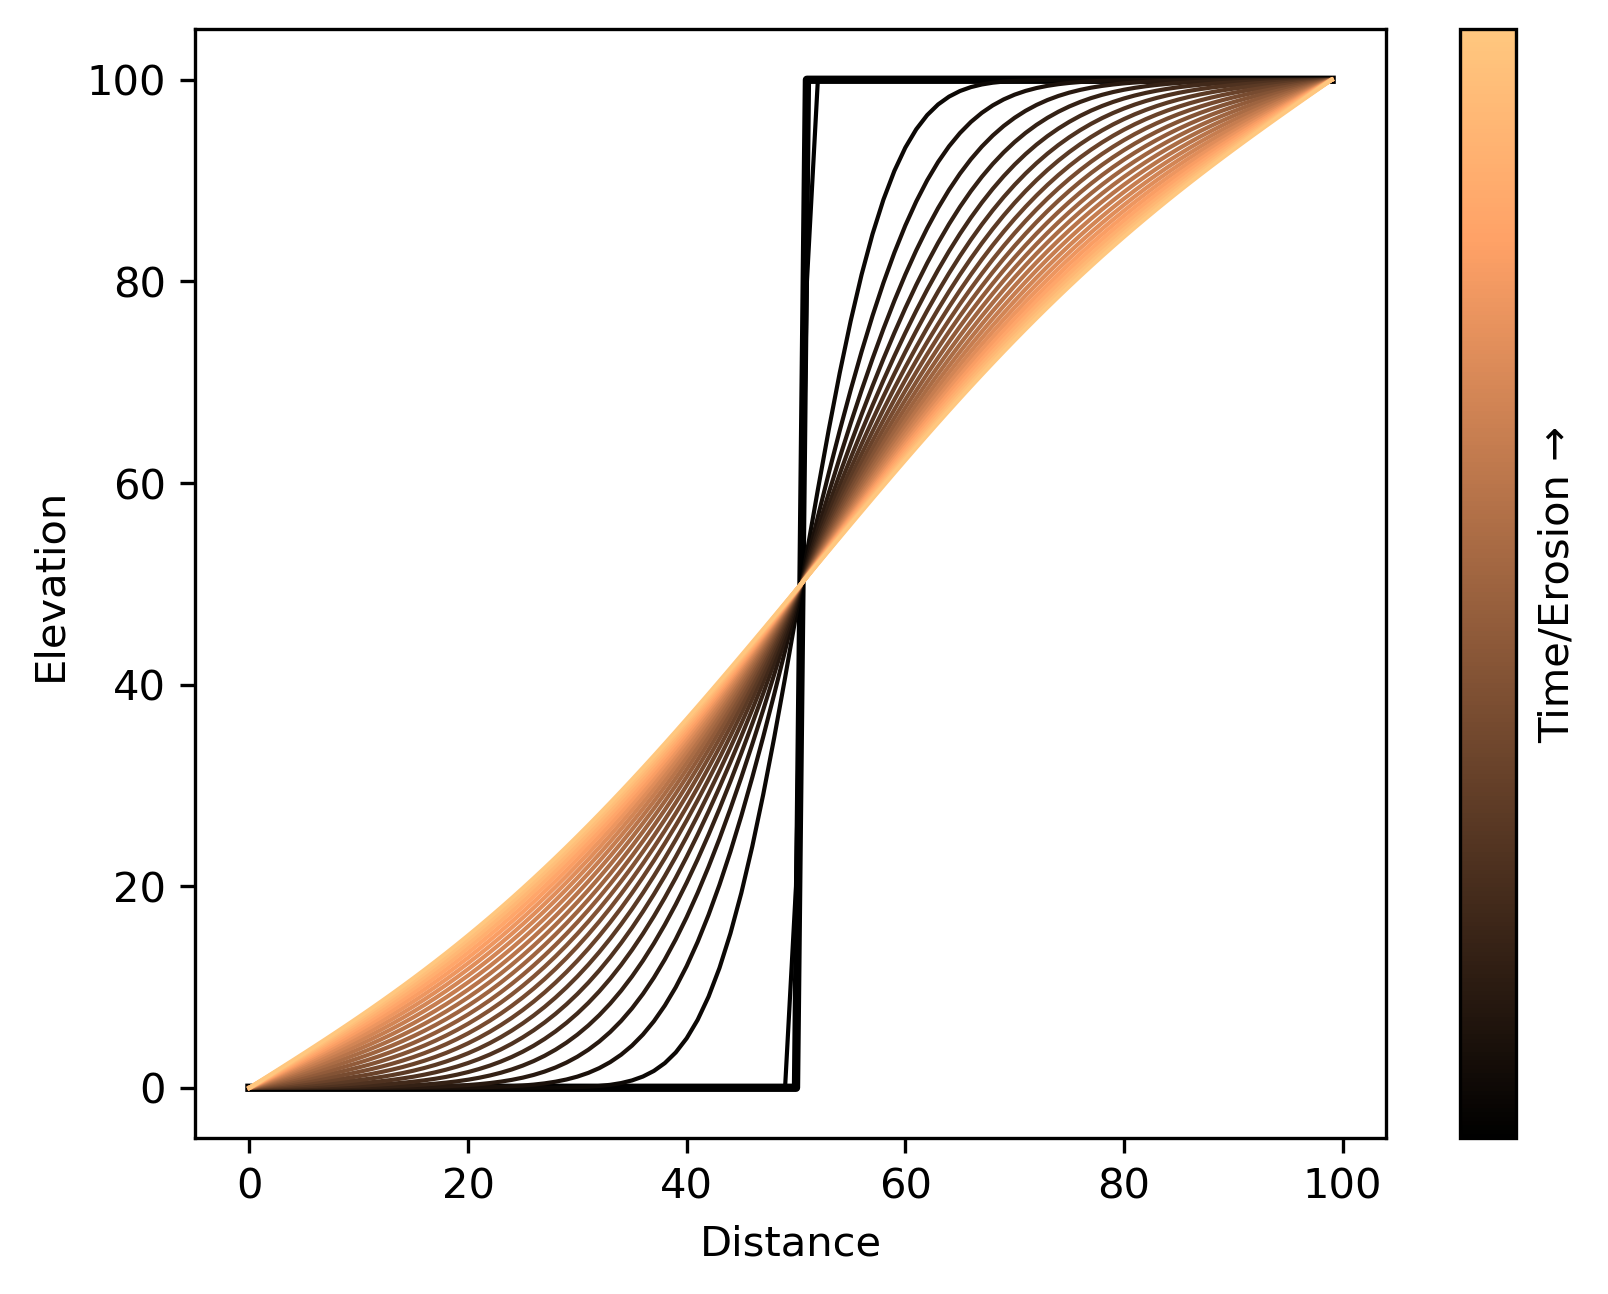

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import copper 
from matplotlib.colors import Normalize

dx = 1
x = np.arange(0, 100, dx, dtype=float)
z = np.zeros(x.shape, dtype=float)
D = 0.01

z[x > 50] += 100

dt = 0.2 * dx * dx / D
total_time = 5*10e3
nts = int(total_time / dt)
z_orig = z.copy()

fig, ax = plt.subplots(dpi=300)
plt.plot(x, z_orig, 'k',lw=2)
colors = copper(np.linspace(0, 1, nts//100))  # Get colors for every 10th iteration
color_idx = 0
n_plots = nts // 100
times = np.linspace(0, total_time, n_plots)
norm = Normalize(vmin=times.min(), vmax=times.max())


for i in range(nts):
    qs = -D * np.diff(z) / dx
    dzdt = -np.diff(qs) / dx
    z[1:-1] += dzdt * dt
    if i % 100 == 0:  
        plt.plot(x, z,lw=1, color=colors[color_idx])
        color_idx += 1
        
sm = plt.cm.ScalarMappable(cmap=copper, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='Erosion →')
# Rotate the colorbar label to point upward
cbar.ax.set_ylabel('Time/Erosion →', rotation=90, va='bottom',labelpad=15)
cbar.ax.set_yticks([])

plt.xlabel('Distance')
plt.ylabel('Elevation')
plt.savefig('Figures/diff_cartoon.png')